# Notebook 02: EDA + Visualizations (Beginner-Friendly)

Goal: help students understand the dataset before modeling.


In [1]:
import logging
import sys
import time
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path


def _project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").is_dir():
        return cwd
    parent = cwd.parent
    if (parent / "src").is_dir():
        return parent
    return cwd


PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import RAW_FILE_PATH
from src.data import basic_cleaning, make_text_feature

LOG_DIR = PROJECT_ROOT / 'logs/notebooks'
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / f"02_eda_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logger = logging.getLogger('nb02')
logger.setLevel(logging.INFO)
logger.handlers.clear()
_fmt = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
_fh = logging.FileHandler(LOG_FILE, encoding='utf-8')
_fh.setFormatter(_fmt)
logger.addHandler(_fh)

@contextmanager
def timed_step(name: str):
    start = time.perf_counter()
    logger.info('START: %s', name)
    print(f"[START] {name}")
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        logger.info('END: %s | elapsed=%.2fs', name, elapsed)
        print(f"[END] {name} | elapsed={elapsed:.2f}s")

sns.set_theme(style='whitegrid')
with timed_step('load_clean_and_text_features'):
    df = pd.read_csv(RAW_FILE_PATH)
    df = basic_cleaning(df)
    df['text'] = make_text_feature(df)

print('project root:', PROJECT_ROOT)
print('Shape:', df.shape)
print('notebook log file:', LOG_FILE)
df.head()


[START] load_clean_and_text_features
[END] load_clean_and_text_features | elapsed=0.11s
project root: C:\Users\akhil\OneDrive\Documents\ML Kaggle DS Projects\womens-e-commerce-reviews
Shape: (23486, 12)
notebook log file: C:\Users\akhil\OneDrive\Documents\ML Kaggle DS Projects\womens-e-commerce-reviews\logs\notebooks\02_eda_20260426_101624.log


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,text
0,0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Absolutely wonderful - silky and sexy and comf...
1,1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Love this dress! it's sooo pretty. i happene...
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws I had such high hopes ...
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy! I love, love, love this jumps..."
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt This shirt is very flattering...


In [2]:
# Data types and null check
display(df.dtypes)
display(df.isnull().sum().sort_values(ascending=False).head(10))


Unnamed: 0                 int64
Clothing ID                int64
Age                        int64
Title                        str
Review Text                  str
Rating                     int64
Recommended IND            int64
Positive Feedback Count    int64
Division Name                str
Department Name              str
Class Name                   str
text                         str
dtype: object

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
dtype: int64

[START] plot_target_distribution


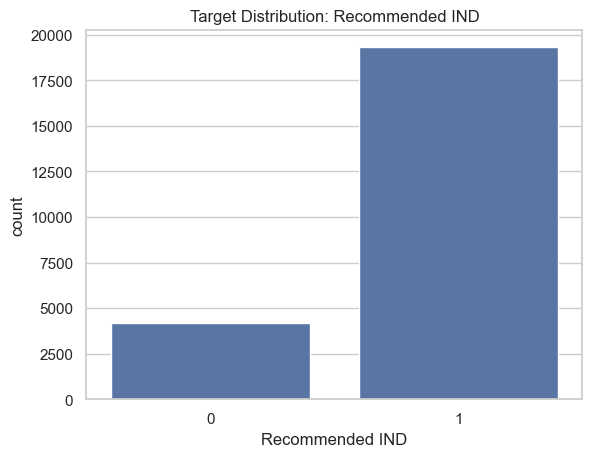

[END] plot_target_distribution | elapsed=0.19s


Recommended IND
1    0.822362
0    0.177638
Name: proportion, dtype: float64

In [3]:
# Target distribution
with timed_step('plot_target_distribution'):
    ax = sns.countplot(data=df, x='Recommended IND')
    ax.set_title('Target Distribution: Recommended IND')
    plt.show()

target_dist = df['Recommended IND'].value_counts(normalize=True)
logger.info('target_distribution=%s', target_dist.to_dict())
target_dist


[START] plot_rating_vs_recommendation


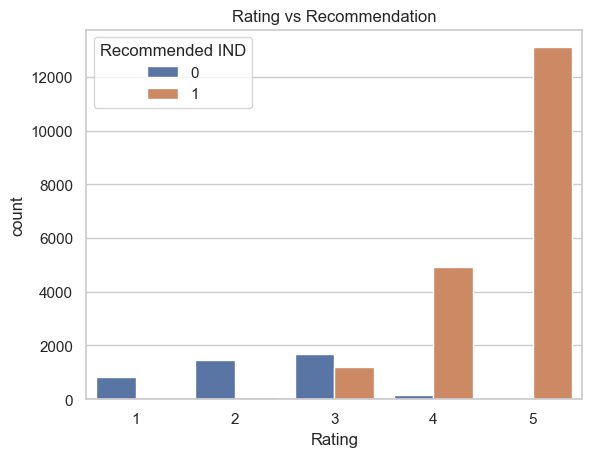

[END] plot_rating_vs_recommendation | elapsed=0.12s


In [4]:
# Rating vs recommendation
with timed_step('plot_rating_vs_recommendation'):
    ax = sns.countplot(data=df, x='Rating', hue='Recommended IND')
    ax.set_title('Rating vs Recommendation')
    plt.show()
logger.info('Completed rating vs recommendation plot')


[START] plot_age_distribution


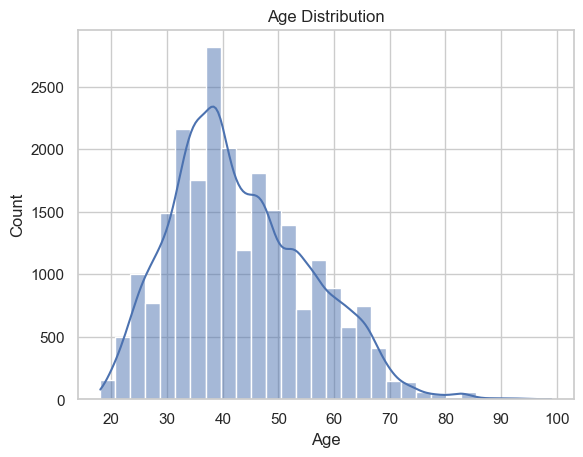

[END] plot_age_distribution | elapsed=0.28s


In [5]:
# Age distribution
with timed_step('plot_age_distribution'):
    ax = sns.histplot(df['Age'], bins=30, kde=True)
    ax.set_title('Age Distribution')
    plt.show()
logger.info('Completed age distribution plot')


,mean,count
Department Name,,
Tops,0.815151,10468
Dresses,0.808197,6319
Bottoms,0.851277,3799
Intimate,0.850144,1735
Jackets,0.836240,1032
Trend,0.739496,119
Unknown,1.000000,14


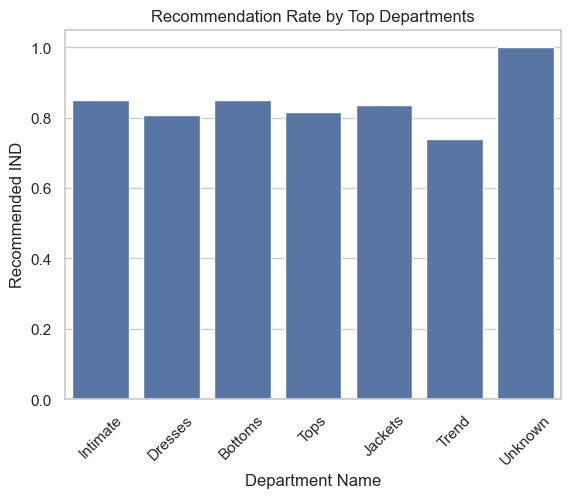

In [6]:
# Department-level recommendation rates
dept_stats = (
    df.groupby('Department Name')['Recommended IND']
    .agg(['mean', 'count'])
    .sort_values('count', ascending=False)
)
display(dept_stats.head(10))

top_depts = dept_stats.head(10).index
plot_df = df[df['Department Name'].isin(top_depts)]
ax = sns.barplot(data=plot_df, x='Department Name', y='Recommended IND', errorbar=None)
ax.set_title('Recommendation Rate by Top Departments')
ax.tick_params(axis='x', rotation=45)
plt.show()


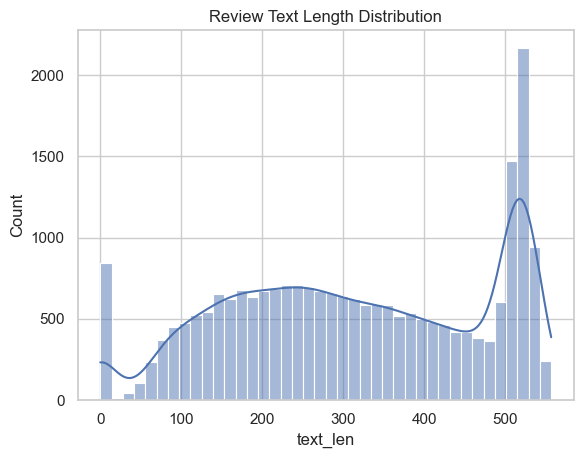

,count,mean,std,min,25%,50%,75%,max
Recommended IND,,,,,,,,
0,4172.0,331.131352,146.246054,0.0,214.0,329.0,475.0,557.0
1,19314.0,310.808015,158.901641,0.0,182.0,305.0,468.0,553.0


In [7]:
# Text length analysis
df['text_len'] = df['text'].str.len()
ax = sns.histplot(df['text_len'], bins=40, kde=True)
ax.set_title('Review Text Length Distribution')
plt.show()

df.groupby('Recommended IND')['text_len'].describe()


## Discussion prompts for students

- Is the target imbalanced?
- Do higher ratings strongly map to recommendation?
- Which departments have lower recommendation rate?
- Does review length correlate with recommendation?
